In [14]:
import os
import time
import pickle
import warnings
import csv
from datetime import datetime, timedelta, date

import requests
import numpy as np
import pandas as pd
from pandas.plotting import scatter_matrix
import statsmodels.api as sm
import holidays
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from scipy.stats import randint, uniform

from sklearn.model_selection import (
    train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

from category_encoders import TargetEncoder
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

# Ophalen data

python version: 3.11.9

## Weer api

In [3]:
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 51.05,
    "longitude": 3.7167,
    "start_date": "2016-10-01",
    "end_date": "2025-04-10",
    "hourly": "temperature_2m,apparent_temperature,rain,snowfall,weather_code,cloud_cover,wind_speed_10m,sunshine_duration",
    "timezone": "auto"
}

In [4]:
response = requests.get(url, params=params)

if response.status_code == 200:
    data = response.json()
    hourly_data = data.get("hourly", {})
    script_dir = os.getcwd()
    csv_file_path = os.path.join(script_dir, ".", "data csv", "weerdataraw.csv")
    os.makedirs(os.path.dirname(csv_file_path), exist_ok=True)

    #open csv
    with open(csv_file_path, mode="w", newline="") as file:
        writer = csv.writer(file)

        #header csv
        header = ["timestamp", "temperature_2m", "apparent_temperature", "rain", "snowfall", "weather_code", "cloud_cover", "wind_speed_10m", "sunshine_duration"]
        writer.writerow(header)

        #naar csv schrijven
        for i in range(len(hourly_data.get("temperature_2m", []))):
            row = [
                hourly_data.get("time", [])[i],
                hourly_data.get("temperature_2m", [])[i],
                hourly_data.get("apparent_temperature", [])[i],
                hourly_data.get("rain", [])[i],
                hourly_data.get("snowfall", [])[i],
                hourly_data.get("weather_code", [])[i],
                hourly_data.get("cloud_cover", [])[i],
                hourly_data.get("wind_speed_10m", [])[i],
                hourly_data.get("sunshine_duration", [])[i]
            ]
            writer.writerow(row)

    print(f"Data weggeschreven: {csv_file_path}")
else:
    print(f"Failed status code: {response.status_code}")

Data weggeschreven: c:\Users\krist\OneDrive\Documents\HoGent IT\ML_kijkcijfers\ML_project_kijkcijfers\.\data csv\weerdataraw.csv


## Kijkcijfer data

In [5]:
start_date = datetime(2016, 10, 1)
end_date = datetime.today()

script_dir = os.getcwd()
output_file = os.path.join(script_dir, "./data csv/kijkcijfersdataraw.csv")

os.makedirs(os.path.dirname(output_file), exist_ok=True)

In [6]:

with open(output_file, mode='w', newline='', encoding='utf-8-sig') as file:
    fieldnames = [
    'dateDiff', 'ranking', 'description', 'channel', 
    'startTime', 'rLength', 'rateInK', 'live'
    ]
    writer = csv.DictWriter(file, fieldnames=fieldnames)
    writer.writeheader()

    # Loop door elke dag
    current_date = start_date
    while current_date <= end_date:
        datum = f"{current_date.year}-{current_date.month}-{current_date.day}"
        url = f"https://api.cim.be/api/cim_tv_public_results_daily_views?dateDiff={datum}&reportType=north"
            
        try:
            response = requests.get(url)
            if response.status_code == 200:
                data = response.json()
                programma_lijst = data.get('hydra:member', [])
                        
                for programma in programma_lijst:
                    try:
                        writer.writerow({
                        'dateDiff': programma.get('dateDiff'),
                        'ranking': programma.get('ranking'),
                        'description': programma.get('description'),
                        'channel': programma.get('channel'),
                        'startTime': programma.get('startTime'),
                        'rLength': programma.get('rLength'),
                        'rateInK': programma.get('rateInK'),
                        'live': programma.get('live')
                        })
                                    
                    except Exception as e:
                        print(f"error {datum}: {e}")         
            else:
                print(f"no data {datum}")
                        
        except Exception as e:
            print(f"error {datum}: {e}")
            
        current_date += timedelta(days=1)
print("data opgehaald")

data opgehaald


# Opkuisen data

In [7]:
def cleanUp(df):
  #nullwaarden verwijderen
  df.dropna(inplace=True)

  # foute namen van kolom Kanaal corrigeren
  df = df[~df['channel'].str.contains(r'[,/]', regex=True, na=False)]

  #tijd aanpassen
  #tijdformaat ..:..:..
  tijd_regex = r'^\d{2}:\d{2}:\d{2}$'
  #omzetten naar datetime
  df['date'] = pd.to_datetime(df['dateDiff']).dt.date
  #filter rijen met formaat
  df = df[df['startTime'].str.match(tijd_regex, na=False) & df['rLength'].str.match(tijd_regex, na=False)].copy()
  #afleveringlengte naar seconden omzetten 
  df['Lengte_sec'] = pd.to_timedelta(df['rLength']).dt.total_seconds().astype(int)
  #kijkers naar int
  df['Kijkers'] = df['rateInK'].dropna().astype(str).str.replace('.', '', regex=False).astype(int)

  #uren met 24+
  def time_cor(rij):
    tijdArr = rij['startTime'].split(':')
    if int(tijdArr[0]) >= 24:
      tijdArr[0] = str(int(tijdArr[0]) - 24).zfill(2)
      
      rij['date'] += timedelta(days=1)
    rij['startTime'] = ':'.join(tijdArr)
    return rij
  
  df = df.apply(time_cor, axis=1)

  #1 kolom voor beide data
  df['FullDate'] = pd.to_datetime(df['date'].astype(str) 
                                  + " " + df['startTime'].astype(str))
  
  #hour en minute voor join later on
  df['hour'] = pd.to_datetime(df['startTime']).dt.hour
  df['minute'] = pd.to_datetime(df['startTime']).dt.minute

  #kolommen verwijderen die niet nodig meer zijn
  df.drop(['startTime', 'rLength', 'rateInK', 'ranking', 'live'], axis=1, inplace=True)

  #de nieuwe dataframe
  df = df[['FullDate', 'date', 'hour','minute', 'channel', 'description', 'Lengte_sec', 'Kijkers']]

  #hernoemen kolommen
  df.rename(columns={'description':'Programma', 'channel':'Kanaal'}, inplace=True)

  return df

In [8]:
Kijkcijfers = pd.read_csv('./data csv/kijkcijfersdataraw.csv')
Kijkcijfers = cleanUp(Kijkcijfers)
Kijkcijfers.sample(10)

,FullDate,date,hour,minute,Kanaal,Programma,Lengte_sec,Kijkers
25456,2020-03-29 18:12:23,2020-03-29,18,12,EEN,DAGELIJKSE KOST,2726,521048
42998,2022-08-04 19:57:04,2022-08-04,19,57,VTM2,B&B ZOEKT LIEF,1520,141255
23268,2019-12-11 21:27:06,2019-12-11,21,27,VIER,DE SLIMSTE MENS TER WERELD,3506,948937
37565,2021-11-24 20:35:39,2021-11-24,20,35,PLAY4,BAKE OFF VLAANDEREN,3338,262867
49317,2023-06-16 21:31:59,2023-06-16,21,31,Canvas,COLETTE,6404,103862
54320,2024-02-22 20:23:20,2024-02-22,20,23,VRT 1,THUIS,1500,1131925
7620,2017-10-18 13:00:04,2017-10-18,13,0,EEN,HET 1 UUR-JOURNAAL,1600,360102
56752,2024-06-22 20:31:12,2024-06-22,20,31,VTM,DE KOTMADAM,1567,148063
14145,2018-09-08 19:36:46,2018-09-08,19,36,VIER,HUIZENJAGERS,2358,94568
59096,2024-10-17 19:59:03,2024-10-17,19,59,PLAY4,DE TAFEL VAN GERT,3660,252179


# Mergen van kijkcijfers en weerdata

In [9]:
weerData = pd.read_csv('./data csv/weerdataraw.csv')
weerData['timestamp'] = pd.to_datetime(weerData['timestamp'])
#naar zelfde formaat als kijkcijfer datum
weerData['datetime'] = weerData['timestamp'].dt.strftime('%Y-%m-%d %H:%M:%S')

#hour voor join later on
weerData['hour'] = pd.to_datetime(weerData['datetime']).dt.hour
weerData['minute'] = pd.to_datetime(weerData['datetime']).dt.minute
weerData['date'] = pd.to_datetime(weerData['datetime']).dt.date

#verwijder kolom
weerData = weerData.drop(columns=['timestamp'])

weerData = weerData[['datetime', 'date' ,'hour', 'minute', 'temperature_2m', 'apparent_temperature', 
                           'rain', 'snowfall', 'weather_code', 'cloud_cover', 
                           'wind_speed_10m', 'sunshine_duration']]

#hernoemen kolommen
weerData.rename(columns={'temperature_2m':'Temperatuur', 'apparent_temperature':'Gevoelstemp', 'wind_speed_10m': 'Windsnelheid', 'rain':'Regen', 'snowfall': 'Sneeuw', 'weather_code':'Weercode', 'cloud_cover':'Bewolking', 'sunshine_duration':'Zonnenschijn'}, inplace=True)

weerData.sample(10)

,datetime,date,hour,minute,Temperatuur,Gevoelstemp,Regen,Sneeuw,Weercode,Bewolking,Windsnelheid,Zonnenschijn
51813,2022-08-29 21:00:00,2022-08-29,21,0,19.1,17.3,0.0,0.0,3,90,12.2,0.00
26425,2019-10-07 01:00:00,2019-10-07,1,0,10.8,8.8,0.0,0.0,2,51,15.1,0.00
36195,2020-11-17 03:00:00,2020-11-17,3,0,11.1,7.1,0.0,0.0,3,100,23.5,0.00
15582,2018-07-12 06:00:00,2018-07-12,6,0,14.4,14.4,0.0,0.0,0,4,8.8,0.00
72368,2025-01-02 08:00:00,2025-01-02,8,0,4.6,2.2,0.0,0.0,2,76,6.5,0.00
6002,2017-06-08 02:00:00,2017-06-08,2,0,13.8,10.6,0.1,0.0,51,100,17.8,0.00
23931,2019-06-25 03:00:00,2019-06-25,3,0,18.8,19.7,0.0,0.0,3,95,10.4,0.00
58475,2023-06-03 11:00:00,2023-06-03,11,0,19.4,15.9,0.0,0.0,0,0,20.2,3600.00
66679,2024-05-10 07:00:00,2024-05-10,7,0,9.3,8.4,0.0,0.0,3,100,5.2,215.16
1699,2016-12-10 19:00:00,2016-12-10,19,0,10.1,7.3,0.0,0.0,3,100,17.1,0.00


In [10]:
kijkcijfersWeer = pd.merge(Kijkcijfers, weerData, on=['date', 'hour'], how='left')

kijkcijfersWeer = kijkcijfersWeer[['FullDate', 'date', 'hour', 'Kanaal', 'Programma', 'Lengte_sec', 'Kijkers', 'Temperatuur', 'Gevoelstemp', 'Regen', 'Sneeuw', 'Weercode', 'Bewolking', 'Windsnelheid', 'Zonnenschijn']]

kijkcijfersWeer.sample(10)

#kijkcijfersWeer.to_csv('./data csv/blablableble.csv')

,FullDate,date,hour,Kanaal,Programma,Lengte_sec,Kijkers,Temperatuur,Gevoelstemp,Regen,Sneeuw,Weercode,Bewolking,Windsnelheid,Zonnenschijn
10804,2018-03-30 18:59:50,2018-03-30,18,VTM,NIEUWS 19U VTM,3065,573000,9.3,5.1,0.8,0.0,53.0,100.0,22.0,0.00
2511,2017-02-06 21:53:04,2017-02-06,21,EEN,VAN GILS & GASTEN,2830,365850,4.9,2.4,0.0,0.0,3.0,100.0,6.5,0.00
21723,2019-09-29 13:40:55,2019-09-29,13,EEN,SPORZA,2895,713889,18.2,14.8,0.1,0.0,51.0,96.0,30.0,3534.33
46923,2023-03-31 16:54:00,2023-03-31,16,VTM,ASPE,2779,140255,11.0,5.2,0.2,0.0,51.0,100.0,34.4,0.00
49559,2023-08-11 14:02:02,2023-08-11,14,VRT 1,LEWIS,5541,177136,25.2,26.2,0.1,0.0,51.0,100.0,13.6,3600.00
41289,2022-06-13 21:47:48,2022-06-13,21,PLAY4,DE AMBASSADE,2883,115188,14.5,13.3,0.0,0.0,0.0,0.0,5.1,3600.00
29581,2020-11-10 19:46:53,2020-11-10,19,EEN,IEDEREEN BEROEMD,1316,1095181,11.0,10.0,0.2,0.0,51.0,70.0,7.9,0.00
45347,2023-01-12 19:00:02,2023-01-12,19,EEN,HET 7 UUR-JOURNAAL,2714,954332,10.1,5.6,0.9,0.0,53.0,100.0,28.8,0.00
40827,2022-05-22 22:32:24,2022-05-22,22,EEN,HET JOURNAAL LAAT,965,249985,17.6,17.0,0.0,0.0,3.0,100.0,5.4,0.00
6590,2017-08-30 20:38:42,2017-08-30,20,VTM,DE KOTMADAM,1605,360696,16.3,14.2,0.0,0.0,3.0,100.0,22.9,0.00


In [11]:
kijkcijfersWeer.dropna(inplace=True)
#csv aanmaken als het niet bestaat
csv_file_path = os.path.join('.','data csv','kijkcijfersWeerRaw.csv')
os.makedirs(os.path.dirname(csv_file_path), exist_ok=True)
#data naar csv
kijkcijfersWeer.to_csv(csv_file_path, index=False)

# Features 

Feestdag, day of the week, weekend, seizoen

In [12]:
cleanData = pd.read_csv('./data csv/kijkcijfersWeerRaw.csv')
cleanData['date'] = pd.to_datetime(cleanData['date'])

#feestdagen
feestdagen = holidays.BE()
cleanData['isFeestdag'] = cleanData['date'].apply(lambda x: 1 if x in feestdagen else 0)

#dag van de week
cleanData['Weekdag'] = cleanData['date'].dt.weekday

#weekend
cleanData['isWeekend'] = cleanData['Weekdag'].apply(lambda x: 1 if x >= 5 else 0)

#seizoen
def seizoenFinder(datum):
    inputDatum = datum.date()
    Y = inputDatum.year
    seizoenen = {
        'lente': (date(Y, 3, 20), date(Y, 6, 20)),
        'zomer': (date(Y, 6, 21), date(Y, 9, 22)),
        'herfst':   (date(Y, 9, 23), date(Y, 12, 20)),
        'winter': (date(Y, 12, 21), date(Y + 1, 3, 19)),
    }

    for seizoen, (start, end) in seizoenen.items():
        if start <= inputDatum <= end:
            return seizoen
    return 'winter'

cleanData['Seizoen'] = cleanData['date'].apply(seizoenFinder)
cleanData.sample(10)

,FullDate,date,hour,Kanaal,Programma,Lengte_sec,Kijkers,Temperatuur,Gevoelstemp,Regen,Sneeuw,Weercode,Bewolking,Windsnelheid,Zonnenschijn,isFeestdag,Weekdag,isWeekend,Seizoen
45270,2023-01-08 19:21:09,2023-01-08,19,EEN,SPORTWEEKEND,1989,837306,8.6,3.6,0.0,0.0,1.0,21.0,25.7,0.00,0,6,1,winter
6590,2017-08-30 20:38:42,2017-08-30,20,VTM,DE KOTMADAM,1605,360696,16.3,14.2,0.0,0.0,3.0,100.0,22.9,0.00,0,2,0,zomer
56664,2024-08-12 22:21:28,2024-08-12,22,PLAY4,GEUBELS EN DE BELGEN,1806,160059,27.3,30.7,0.0,0.0,1.0,29.0,8.0,0.00,0,0,0,zomer
44750,2022-12-13 18:59:38,2022-12-13,18,VTM,NIEUWS 19U VTM,3385,725399,-2.4,-7.0,0.0,0.0,3.0,100.0,12.6,0.00,0,1,0,herfst
43591,2022-10-14 18:59:38,2022-10-14,18,VTM,NIEUWS 19U VTM,3179,605797,14.5,14.8,0.0,0.0,3.0,100.0,3.7,1041.76,0,4,0,herfst
33133,2021-05-07 20:00:04,2021-05-07,20,Canvas,TER ZAKE,1728,192711,10.5,7.6,0.0,0.0,0.0,18.0,7.1,3600.00,0,4,0,lente
33643,2021-06-02 18:30:51,2021-06-02,18,EEN,BLOKKEN,1634,577774,27.3,26.4,0.0,0.0,1.0,49.0,9.0,3600.00,0,2,0,lente
1639,2016-12-25 21:20:38,2016-12-25,21,EEN,EIGEN KWEEK,3072,1210308,10.6,6.7,0.0,0.0,3.0,100.0,24.8,0.00,1,6,1,winter
6580,2017-08-30 19:45:08,2017-08-30,19,EEN,IEDEREEN BEROEMD,1039,762319,16.5,14.4,0.8,0.0,53.0,100.0,25.0,0.00,0,2,0,zomer
58269,2024-11-05 18:29:40,2024-11-05,18,VRT 1,BLOKKEN,1627,654651,9.2,7.8,0.0,0.0,3.0,100.0,6.0,0.00,0,1,0,herfst


In [13]:
script_dir = os.getcwd()
csv_file_path = os.path.join(script_dir, ".", "data csv", "kijkcijfersWeer.csv")
os.makedirs(os.path.dirname(csv_file_path), exist_ok=True)
cleanData.to_csv('./data csv/kijkcijfersWeer.csv')

# Model training

In [40]:
cleanData = pd.read_csv('./data csv/kijkcijfersWeer.csv')
cleanData.drop(columns=['Unnamed: 0'], inplace=True)
cleanData.sample(5)

,FullDate,date,hour,Kanaal,Programma,Lengte_sec,Kijkers,Temperatuur,Gevoelstemp,Regen,Sneeuw,Weercode,Bewolking,Windsnelheid,Zonnenschijn,isFeestdag,Weekdag,isWeekend,Seizoen
5383,2017-07-01 20:39:29,2017-07-01,20,EEN,SLEEPLESS IN SEATTLE,5809,398717,16.4,15.4,0.0,0.0,3.0,84.0,11.8,0.00,0,5,1,zomer
60653,2025-03-04 22:15:14,2025-03-04,22,VRT CANVAS,DE KROKUSQUIZ,3013,485103,5.7,2.5,0.0,0.0,0.0,0.0,9.7,0.00,0,1,0,winter
16451,2019-01-06 12:59:54,2019-01-06,12,VTM,NIEUWS 13U VTM,2159,317458,5.3,2.7,0.0,0.0,3.0,92.0,5.6,0.00,0,6,1,winter
40221,2022-04-27 21:48:53,2022-04-27,21,VTM,VREDERECHTERS,2960,325665,8.8,4.5,0.0,0.0,0.0,0.0,17.7,1179.27,0,2,0,lente
26304,2020-05-15 20:44:16,2020-05-15,20,VTM,"MISSION IMPOSSIBLE, FALLOUT",8029,428110,12.9,9.0,0.0,0.0,0.0,1.0,15.3,3600.00,0,4,0,lente


Histogrammen

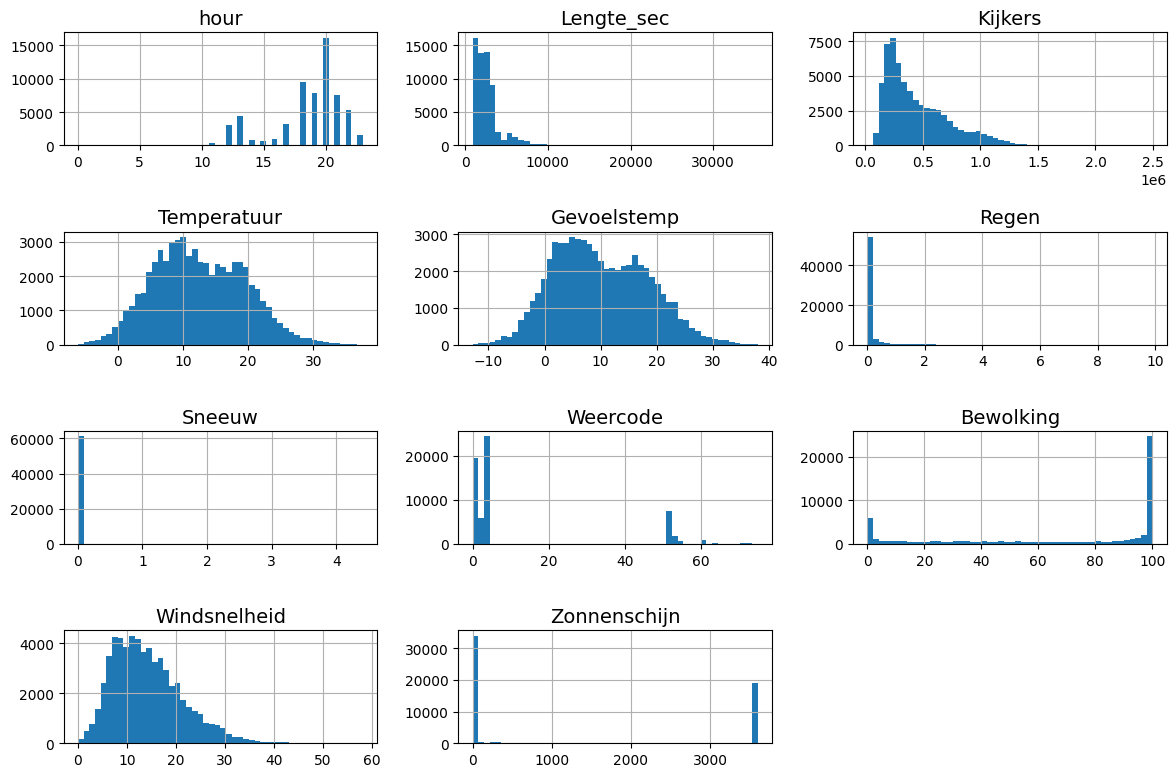

In [41]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
histogram = cleanData[["hour","Lengte_sec","Kijkers","Temperatuur","Gevoelstemp","Regen","Sneeuw","Weercode","Bewolking","Windsnelheid","Zonnenschijn"]]
# Histogrammen genereren van dataset
histogram.hist(bins=50, figsize=(12,8))
plt.tight_layout()
plt.show()

Uit deze verzameling van histogrammen zien we de verdeling van de data binnen de kolommen respectievelijk.

Scatter plot

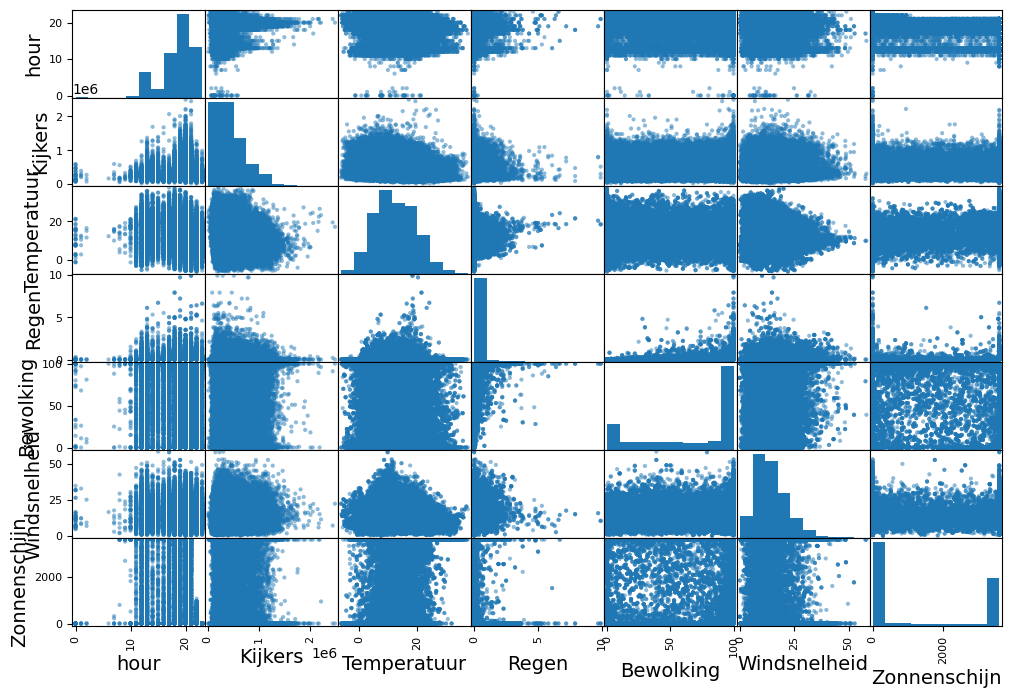

In [42]:
scatter = ["hour","Kijkers","Temperatuur","Regen","Bewolking","Windsnelheid","Zonnenschijn"]
pd.plotting.scatter_matrix(cleanData[scatter], figsize=(12, 8));

Op deze verzameling van scattergrafieken zien we wat de verbanden zijn tussen de kolommen. Diagonaal is het gewoon hun eigen grafiek omdat het verband 1 op 1 is.

Correlatiematrix

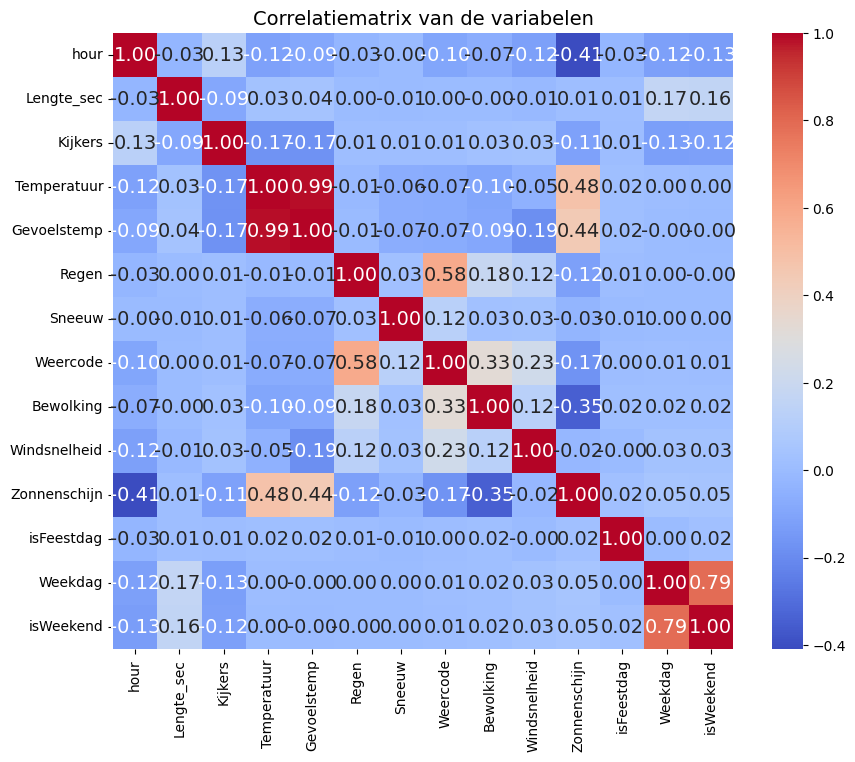

In [43]:
num = cleanData.select_dtypes(include=[np.number])
corr = num.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlatiematrix van de variabelen")
plt.show()

Uit deze correlatiematrix zien we dat het uur opmerkelijk de hoogste correlatie heeft als het om kijkers gaat.

Kijkers per uur in de dag

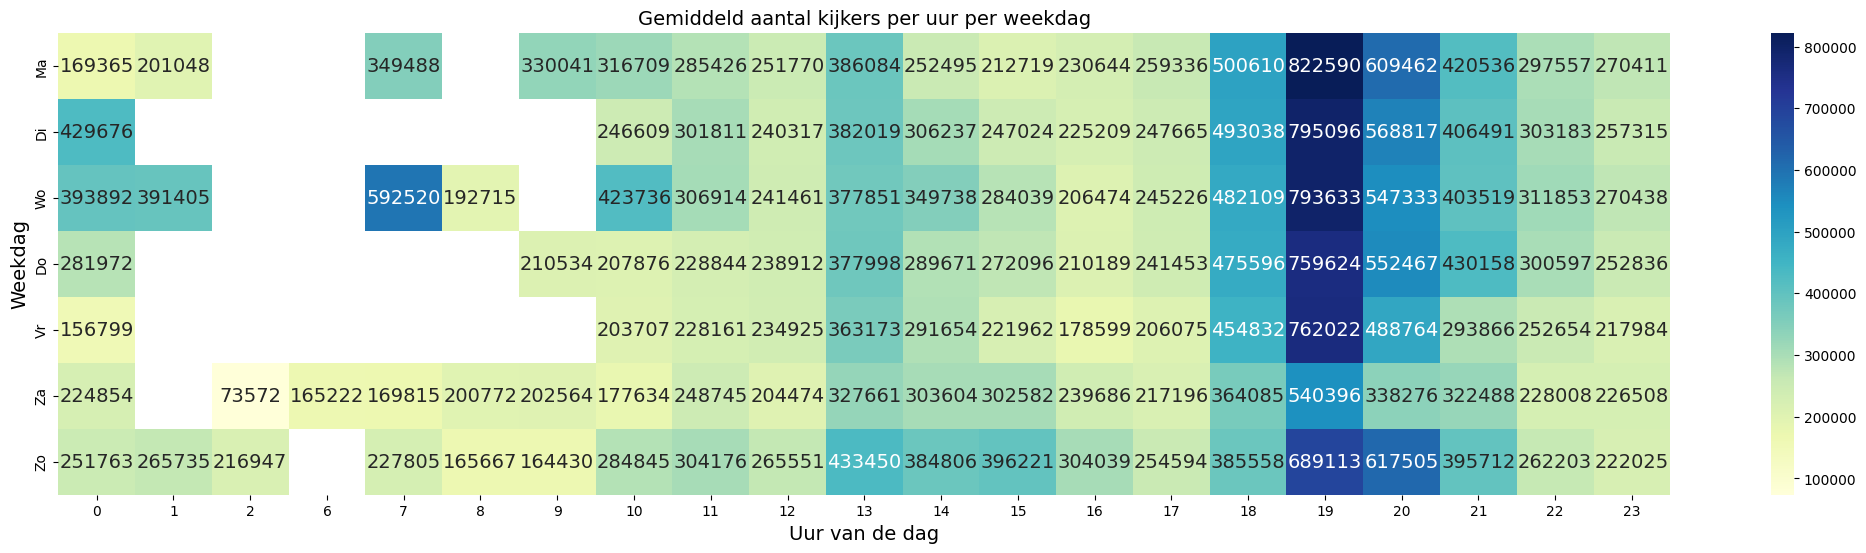

In [44]:
dagen_map = {
    0: "Ma",
    1: "Di",
    2: "Wo",
    3: "Do",
    4: "Vr",
    5: "Za",
    6: "Zo"
}
cleanData['Weekdag'] = cleanData['Weekdag'].map(dagen_map)

pivot = cleanData.pivot_table(index='Weekdag', columns='hour', values='Kijkers', aggfunc='mean')
pivot = pivot.reindex(index=["Ma", "Di", "Wo", "Do", "Vr", "Za", "Zo"])  # correcte volgorde
plt.figure(figsize=(26, 6))
sns.heatmap(pivot, cmap="YlGnBu", annot=True, fmt=".0f")
plt.xlabel("Uur van de dag")
plt.ylabel("Weekdag")
plt.title("Gemiddeld aantal kijkers per uur per weekdag")
plt.show()

Hierop is te zien dat meeste mensen rond 19 uur naar TV kijken, in de nacht en vroege ochtend (1-9uur) zien we gaten doordat TV kanalen anticiperen dat er amper mensen TV kijken en dus niets bepaald uitzenden.

Kijkers per seizoen

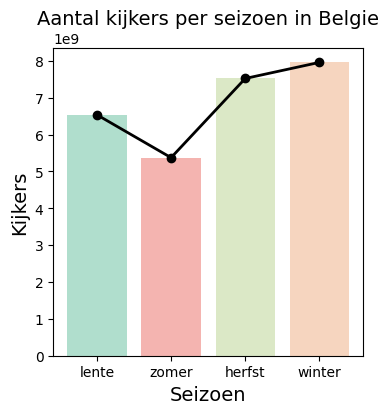

In [45]:
#aantal kijkers per seizoen
kijkersPerSeizoen = cleanData.groupby('Seizoen')['Kijkers'].sum().reindex(['lente', 'zomer', 'herfst', 'winter'])
# Aangepaste kleuren voor elk seizoen
kleuren = ['#a8e6cf', '#ffaaa5', '#dcedc1', '#ffd3b6']

plt.figure(figsize=(4,4))
sns.barplot(x=kijkersPerSeizoen.index, y=kijkersPerSeizoen.values, palette=kleuren)

#trendlijn
plt.plot(kijkersPerSeizoen.index, kijkersPerSeizoen.values, color='black', marker='o', linewidth=2)

plt.xlabel('Seizoen')
plt.ylabel('Kijkers')
plt.title('Aantal kijkers per seizoen in Belgie')
plt.show()

In koudere seizoenen zien we aanzienlijk meer kijkers.

Kijkers per maand

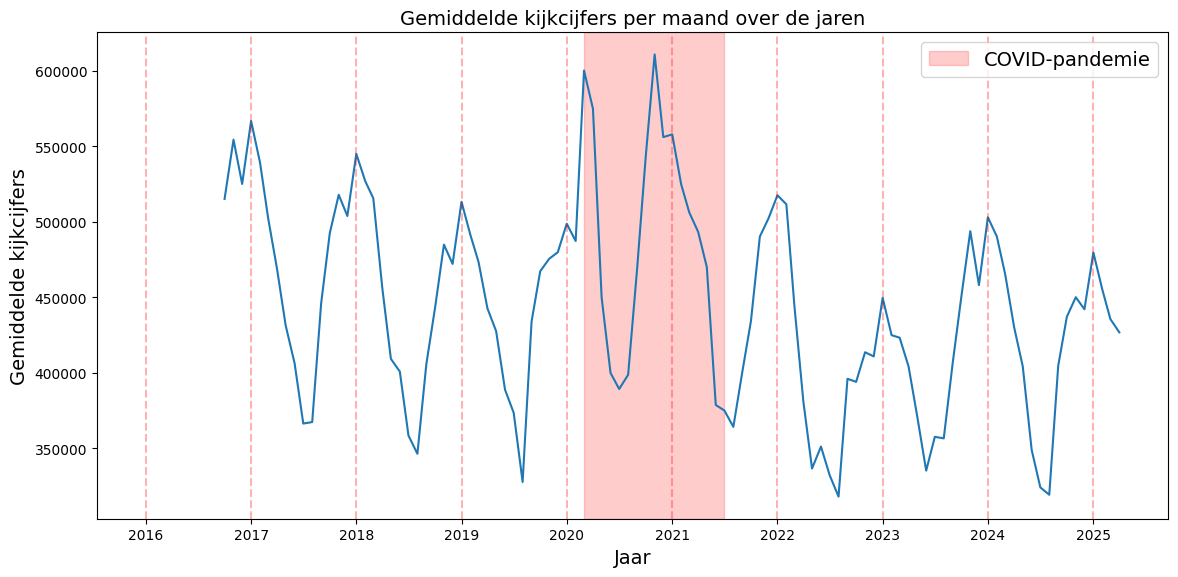

In [46]:
cleanData['date'] = pd.to_datetime(cleanData['date'])
cleanData['month'] = cleanData['date'].dt.to_period('M')

maandelijks = cleanData.groupby(['month'])['Kijkers'].mean().reset_index()
maandelijks['date'] = maandelijks['month'].dt.to_timestamp()

plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='Kijkers', data=maandelijks)
plt.title("Gemiddelde kijkcijfers per maand over de jaren")
plt.xlabel("Jaar")
plt.ylabel("Gemiddelde kijkcijfers")

# Rode verticale lijnen voor elk nieuw jaar
years = maandelijks['date'].dt.year.unique()
for year in years:
    plt.axvline(pd.Timestamp(f'{year}-01-01'), color='red', linestyle='--', alpha=0.3)

# Rode transparante band voor COVID-pandemie periode (maart 2020 tot juni 2021)
covid_start = pd.Timestamp('2020-03-01')
covid_end = pd.Timestamp('2021-06-30')
plt.axvspan(covid_start, covid_end, color='red', alpha=0.2, label='COVID-pandemie')

plt.legend()
plt.tight_layout()
plt.show()

We zien een percistente daling van kijkers over de jaren wat te verklaren is met substituten zoals Disney+ en Netflix. In de periode van corona was er een abnormale stijging van kijkers te verklaren door de lockdown. De zomers zien we enorm weinig kijkers doordat deze vermoedelijk buiten zijn of op vakantie door het warme weer.

Aantal kijkers per weekdag

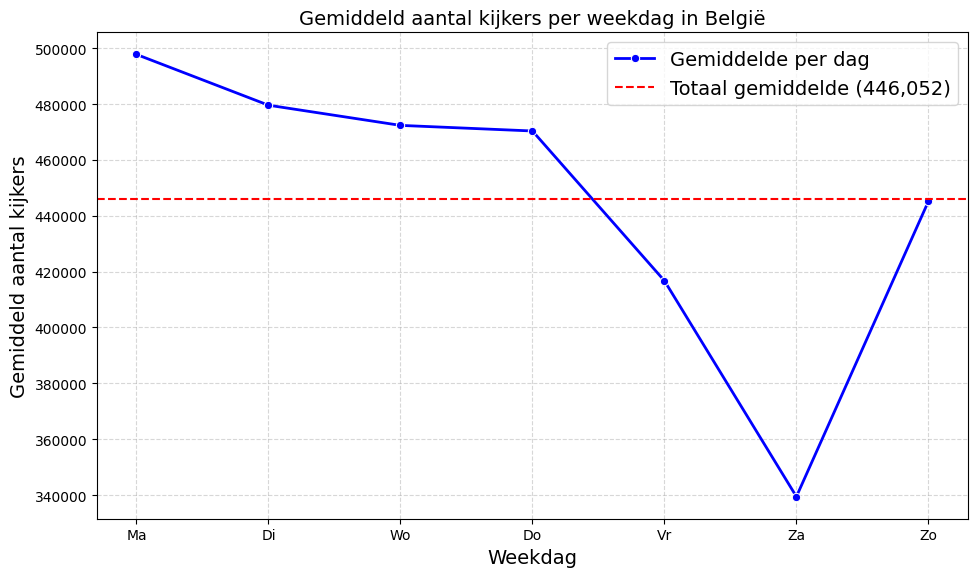

In [47]:
dagen_volgorde = ['Ma', 'Di', 'Wo', 'Do', 'Vr', 'Za', 'Zo']
cleanData['Weekdag'] = pd.Categorical(cleanData['Weekdag'], categories=dagen_volgorde, ordered=True)

avgKijkersWeekdag = cleanData.groupby('Weekdag')['Kijkers'].mean()

totaal_gemiddelde = cleanData['Kijkers'].mean()

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(x=avgKijkersWeekdag.index, y=avgKijkersWeekdag.values, marker='o', color='blue', linewidth=2, label='Gemiddelde per dag')
plt.axhline(totaal_gemiddelde, color='red', linestyle='--', label=f'Totaal gemiddelde ({int(totaal_gemiddelde):,})')
plt.title('Gemiddeld aantal kijkers per weekdag in België')
plt.xlabel('Weekdag')
plt.ylabel('Gemiddeld aantal kijkers')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Opvallend zien we enorm veel mensen kijken op een maandag, dit zakt af en ziet een enorme daling op vrijdag en zaterdag waar ze ver onder het gemiddelde zitten. Op Zondag stijgt het weer naar het gemiddelde.

Meest bekeken kanalen en programma's

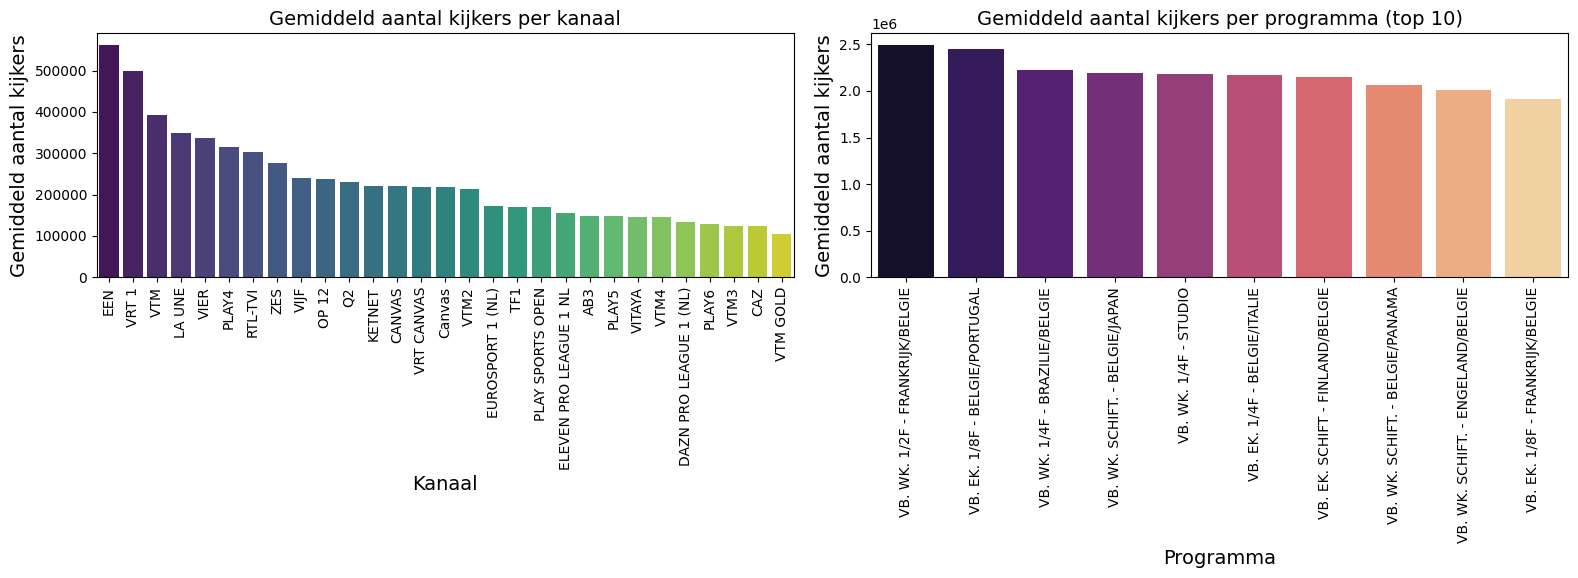

In [54]:
avgKijkersKanaal = cleanData.groupby('Kanaal')['Kijkers'].mean()
avgKijkersKanaal = avgKijkersKanaal.sort_values(ascending=False)
avgKijkersProgramma = cleanData.groupby('Programma')['Kijkers'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot kanaal
sns.barplot(x=avgKijkersKanaal.index, y=avgKijkersKanaal.values, palette='viridis', ax=axes[0])
axes[0].set_title('Gemiddeld aantal kijkers per kanaal')
axes[0].set_xlabel('Kanaal')
axes[0].set_ylabel('Gemiddeld aantal kijkers')
axes[0].tick_params(axis='x', rotation=90)

# Plot programma (top 10)
sns.barplot(x=top10Programmas.index, y=top10Programmas.values, palette='magma', ax=axes[1])
axes[1].set_title('Gemiddeld aantal kijkers per programma (top 10)')
axes[1].set_xlabel('Programma')
axes[1].set_ylabel('Gemiddeld aantal kijkers')
axes[1].tick_params(axis='x', rotation=90)


plt.tight_layout()
plt.show()

De bekendste kanalen zijn EEN en VRT 1, gevolgd door VTM. De gemiddeld meest bekeken programma's zijn steeds voetbalwedstrijden doordat deze vaak uniek zijn en veel kijkers aantrekken. 

Verhouding kijkers en temperatuur

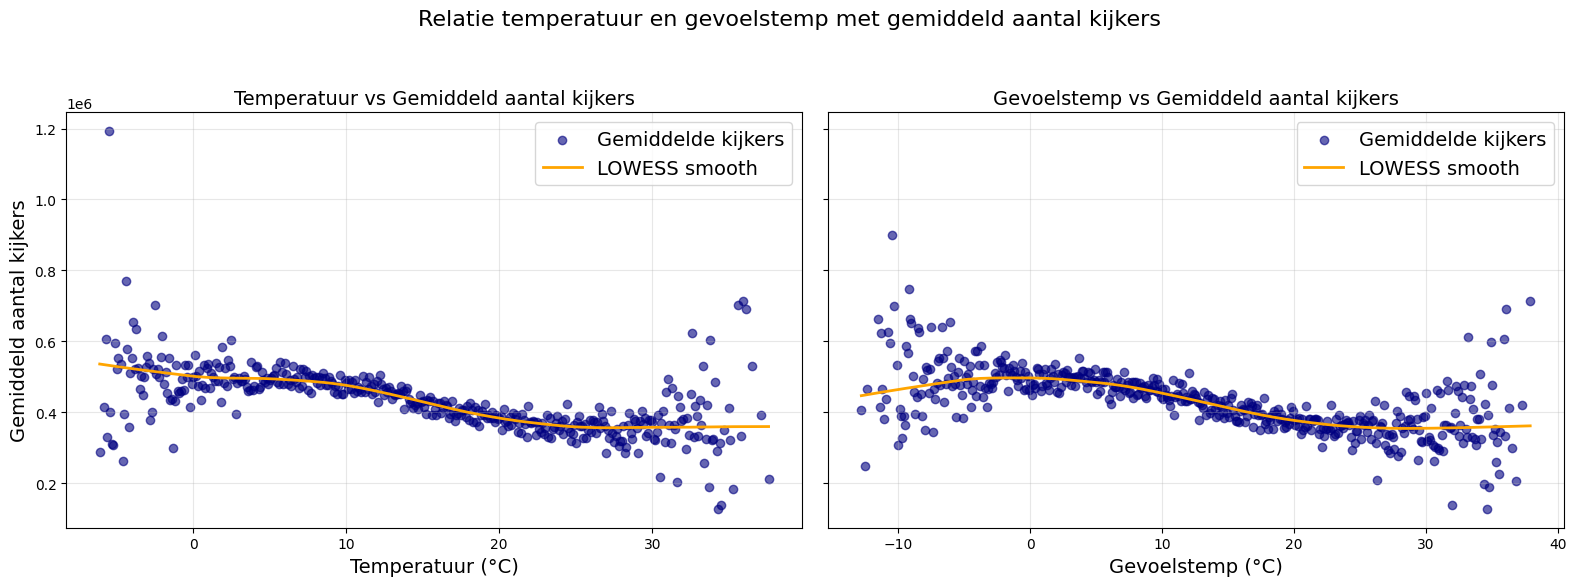

In [49]:
# Gemiddelde kijkers per Temperatuur
temp_kijkers = cleanData.groupby('Temperatuur')['Kijkers'].mean().reset_index()

# Gemiddelde kijkers per Gevoelstemp
gevoelstemp_kijkers = cleanData.groupby('Gevoelstemp')['Kijkers'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot 1: Temperatuur vs Kijkers
axes[0].scatter(temp_kijkers['Temperatuur'], temp_kijkers['Kijkers'], color='navy', alpha=0.6, label='Gemiddelde kijkers')
lowess = sm.nonparametric.lowess
smoothed1 = lowess(temp_kijkers['Kijkers'], temp_kijkers['Temperatuur'], frac=0.3)
axes[0].plot(smoothed1[:, 0], smoothed1[:, 1], color='orange', linewidth=2, label='LOWESS smooth')
axes[0].set_xlabel('Temperatuur (°C)')
axes[0].set_ylabel('Gemiddeld aantal kijkers')
axes[0].set_title('Temperatuur vs Gemiddeld aantal kijkers')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Plot 2: Gevoelstemp vs Kijkers
axes[1].scatter(gevoelstemp_kijkers['Gevoelstemp'], gevoelstemp_kijkers['Kijkers'], color='navy', alpha=0.6, label='Gemiddelde kijkers')
smoothed2 = lowess(gevoelstemp_kijkers['Kijkers'], gevoelstemp_kijkers['Gevoelstemp'], frac=0.3)
axes[1].plot(smoothed2[:, 0], smoothed2[:, 1], color='orange', linewidth=2, label='LOWESS smooth')
axes[1].set_xlabel('Gevoelstemp (°C)')
axes[1].set_title('Gevoelstemp vs Gemiddeld aantal kijkers')
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.suptitle('Relatie temperatuur en gevoelstemp met gemiddeld aantal kijkers', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Hieruit kunnen we zien dat wanneer de temperatuur op extremen zit (te warm of te koud) dat mensen meer TV kijken

Meest bekeken programma's en kanalen

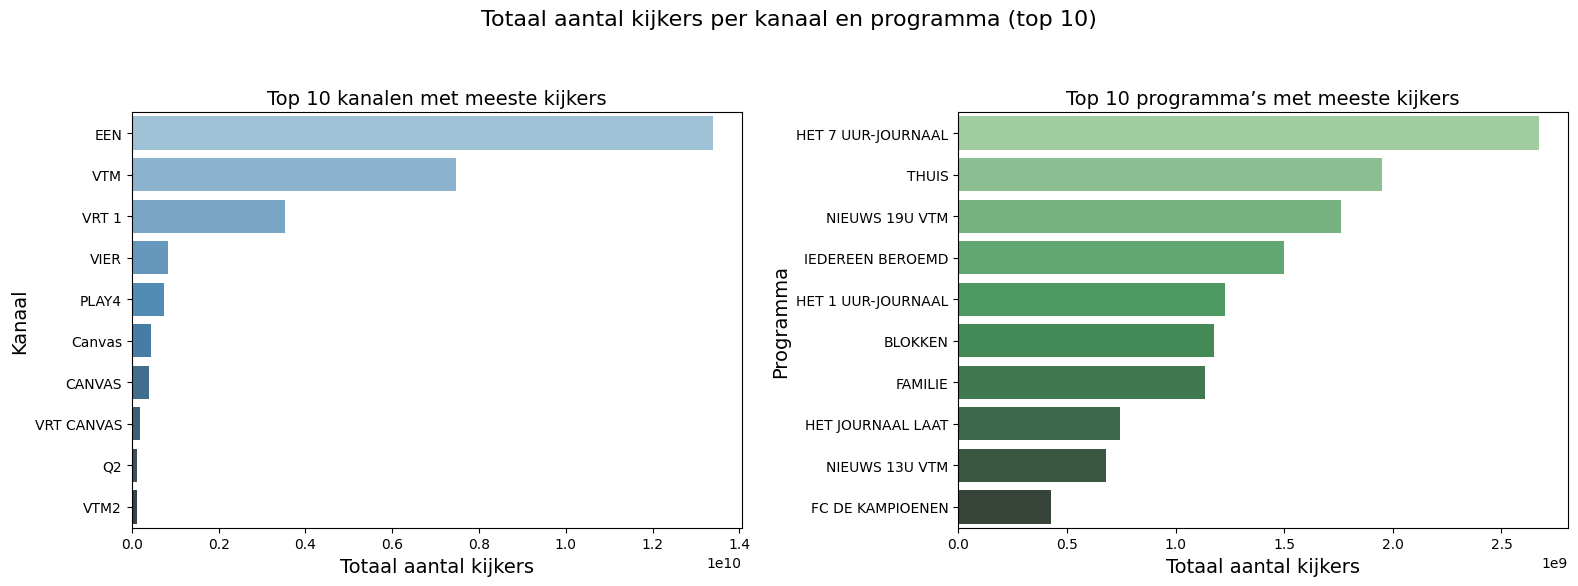

In [52]:
# Som kijkers per Kanaal (top 10)
somKijkersKanaal = cleanData.groupby('Kanaal')['Kijkers'].sum().sort_values(ascending=False).head(10)

# Som kijkers per Programma (top 10)
somKijkersProgramma = cleanData.groupby('Programma')['Kijkers'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Kanaal
sns.barplot(x=somKijkersKanaal.values, y=somKijkersKanaal.index, ax=axes[0], palette="Blues_d")
axes[0].set_title('Top 10 kanalen met meeste kijkers')
axes[0].set_xlabel('Totaal aantal kijkers')
axes[0].set_ylabel('Kanaal')

# Plot 2: Programma
sns.barplot(x=somKijkersProgramma.values, y=somKijkersProgramma.index, ax=axes[1], palette="Greens_d")
axes[1].set_title('Top 10 programma’s met meeste kijkers')
axes[1].set_xlabel('Totaal aantal kijkers')
axes[1].set_ylabel('Programma')

fig.suptitle('Totaal aantal kijkers per kanaal en programma (top 10)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Het is duidelijk dat EEN het meest bekeken kanaal is. Nieuwsprogramma's op 7 uur doen het zeer goed, als ook het zeer populaire programma Thuis.

reverse map

In [25]:
# Omgekeerde mapping
reverse_map = {
    "Ma": 0,
    "Di": 1,
    "Wo": 2,
    "Do": 3,
    "Vr": 4,
    "Za": 5,
    "Zo": 6
}

# Toepassen op de 'Weekdag'-kolom
cleanData['Weekdag'] = cleanData['Weekdag'].map(reverse_map).astype(int)

### lag features toevoegen

In [26]:
def lagFeatures(df, n):
  for i in range(1,n+1):
    df[f'KijkersLag{i}'] = df.sort_values('FullDate').groupby('Programma')['Kijkers'].shift(i).fillna(df.groupby('Programma')['Kijkers'].transform('mean'))
  return df

In [27]:
cleanData = lagFeatures(cleanData, 3)
cleanData['Kanaal'] = cleanData['Kanaal'].str.replace(' ', '_')

print(cleanData['Kanaal'].unique())

cleanData[cleanData['Programma'] == 'THUIS'][['FullDate', 'Kijkers', 'KijkersLag1', 'KijkersLag2', 'KijkersLag3']]

['EEN' 'VTM' 'CANVAS' 'VIER' 'VIJF' 'Q2' 'VITAYA' 'OP_12' 'ZES' 'LA_UNE'
 'RTL-TVI' 'TF1' 'AB3' 'KETNET' 'Canvas' 'CAZ' 'VTM2'
 'ELEVEN_PRO_LEAGUE_1_NL' 'VTM3' 'VTM4' 'PLAY_SPORTS_OPEN' 'PLAY4' 'PLAY5'
 'EUROSPORT_1_(NL)' 'PLAY6' 'VRT_1' 'VRT_CANVAS' 'VTM_GOLD'
 'DAZN_PRO_LEAGUE_1_(NL)']


,FullDate,Kijkers,KijkersLag1,KijkersLag2,KijkersLag3
40,2016-10-03 20:14:23,1268561,1.060382e+06,1.060382e+06,1.060382e+06
60,2016-10-04 20:09:27,1169791,1.268561e+06,1.060382e+06,1.060382e+06
80,2016-10-05 20:13:52,1244502,1.169791e+06,1.268561e+06,1.060382e+06
121,2016-10-07 19:57:34,1156477,1.244502e+06,1.169791e+06,1.268561e+06
180,2016-10-10 19:59:00,1315826,1.156477e+06,1.244502e+06,1.169791e+06
...,...,...,...,...,...
61265,2025-04-04 20:24:13,956032,1.029899e+06,9.989180e+05,1.074137e+06
61325,2025-04-07 20:14:35,1021508,9.560320e+05,1.029899e+06,9.989180e+05
61345,2025-04-08 20:13:09,1014480,1.021508e+06,9.560320e+05,1.029899e+06
61365,2025-04-09 20:19:53,953207,1.014480e+06,1.021508e+06,9.560320e+05


## Encoding

In [28]:
#kardinaliteiten voor betere toepassingen
for kolom in cleanData.columns:
  print(f'{kolom}: {cleanData[kolom].nunique()}')

FullDate: 61318
date: 3051
hour: 21
Kanaal: 29
Programma: 5961
Lengte_sec: 6774
Kijkers: 58864
Temperatuur: 414
Gevoelstemp: 478
Regen: 62
Sneeuw: 25
Weercode: 13
Bewolking: 101
Windsnelheid: 456
Zonnenschijn: 3555
isFeestdag: 2
Weekdag: 7
isWeekend: 2
Seizoen: 4
month: 103
KijkersLag1: 59000
KijkersLag2: 56717
KijkersLag3: 55153


#### one hot encoding

In [29]:
#one hot encoding voor lage cardinaliteit
oneHotEnc = OneHotEncoder(handle_unknown="ignore")
lageKardinaliteit = cleanData[[ 'hour','Kanaal', 'isFeestdag', 'Weekdag', 'Seizoen']]
oneHot = oneHotEnc.fit_transform(lageKardinaliteit)
dfOneHot = pd.DataFrame(oneHot.toarray(), 
                            columns=oneHotEnc.get_feature_names_out(), 
                            index=lageKardinaliteit.index)

cleanData = cleanData.drop(columns=['hour', 'Kanaal', 'isFeestdag', 'Weekdag', 'Seizoen'])
cleanData = pd.concat([cleanData, dfOneHot], axis=1)

cleanData.sample(5)

,FullDate,date,Programma,Lengte_sec,Kijkers,Temperatuur,Gevoelstemp,Regen,Sneeuw,Weercode,...,Weekdag_1,Weekdag_2,Weekdag_3,Weekdag_4,Weekdag_5,Weekdag_6,Seizoen_herfst,Seizoen_lente,Seizoen_winter,Seizoen_zomer
35640,2021-09-10 19:47:08,2021-09-10,IEDEREEN BEROEMD,1352,724232,21.8,22.5,0.1,0.0,51.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
59503,2025-01-05 23:04:59,2025-01-05,HET JOURNAAL LAAT,956,170042,11.4,7.6,0.2,0.0,51.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1900,2017-01-07 20:42:30,2017-01-07,FC DE KAMPIOENEN,2098,712771,2.9,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
60816,2025-03-12 18:08:43,2025-03-12,DAGELIJKSE KOST,926,361036,6.6,3.2,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
16183,2018-12-24 20:39:57,2018-12-24,VREDE OP AARDE,3368,469504,3.5,0.8,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [30]:
#opslaan bij models
modelsDir = os.getcwd()
modelFile = os.path.join(modelsDir, ".",
                          "models", "oneHotEncoder.pkl")
os.makedirs(os.path.dirname(modelFile), exist_ok=True)
with open(modelFile, 'wb') as m:
  pickle.dump(oneHotEnc, m)

### target encoding

In [31]:
#target encoding voor medium kardinaliteiten
targetEncoding = TargetEncoder()
medKardinaliteit = cleanData[['date', 'Programma', 'Lengte_sec', 'Temperatuur', 'Gevoelstemp', 'Regen', 'Bewolking', 'Windsnelheid', 'Zonnenschijn']]
#verdere feature engineering op vorig model
target = targetEncoding.fit_transform(medKardinaliteit, cleanData['Programma'])
target.sample(10)

,date,Programma,Lengte_sec,Temperatuur,Gevoelstemp,Regen,Bewolking,Windsnelheid,Zonnenschijn
31415,2021-02-10,903.000000,1464,-1.4,-6.8,0.0,100.0,15.3,0.00
55232,2024-05-26,2553.000000,2662,18.4,16.8,0.1,17.0,16.6,3600.00
36089,2021-10-02,5137.000000,1413,15.8,11.3,2.4,100.0,39.3,0.00
28260,2020-09-05,2646.793518,15736,17.7,15.0,0.1,49.0,18.5,3600.00
23368,2019-12-20,2548.000000,1622,12.3,6.9,0.5,100.0,35.9,0.00
13048,2018-07-20,2723.550610,2523,21.0,20.5,0.4,100.0,9.2,0.00
41819,2022-07-14,2548.000000,1984,20.4,19.6,0.0,100.0,11.2,2095.63
50198,2023-09-12,834.000000,928,20.4,21.9,0.0,100.0,7.6,632.91
43070,2022-09-18,3266.000000,1980,12.6,9.0,1.2,100.0,24.7,0.00
49623,2023-08-14,1739.228347,3163,18.7,18.4,0.0,41.0,14.0,0.00


In [32]:
cleanData = cleanData.drop(columns=['date', 'Programma', 'Lengte_sec', 'Temperatuur', 'Gevoelstemp', 'Regen', 'Bewolking', 'Windsnelheid', 'Zonnenschijn'])
cleanData = pd.concat([cleanData, target], axis=1)
cleanData.sample(5)

,FullDate,Kijkers,Sneeuw,Weercode,isWeekend,month,KijkersLag1,KijkersLag2,KijkersLag3,hour_0,...,Seizoen_zomer,date,Programma,Lengte_sec,Temperatuur,Gevoelstemp,Regen,Bewolking,Windsnelheid,Zonnenschijn
15994,2018-12-14 16:54:09,203347,0.0,3.0,0,2018-12,204873.0,201213.0,208751.0,0.0,...,0.0,2018-12-14,1454.000000,2884,2.2,-1.4,0.0,87.0,7.4,0.0
60354,2025-02-17 21:22:18,410043,0.0,3.0,0,2025-02,443146.0,428359.0,459517.0,0.0,...,0.0,2025-02-17,1866.105372,3073,-0.3,-4.7,0.0,100.0,10.9,0.0
54280,2024-04-08 22:17:43,202075,0.0,63.0,0,2024-04,168524.0,167418.0,173553.0,0.0,...,0.0,2024-04-08,546.000000,2668,15.3,14.3,3.6,100.0,13.6,0.0
19773,2019-06-21 20:00:06,136542,0.0,0.0,0,2019-06,259229.0,204924.0,163048.0,0.0,...,1.0,2019-06-21,3418.000000,1920,16.6,14.3,0.0,2.0,11.7,3600.0
30236,2020-12-13 22:40:18,169714,0.0,3.0,1,2020-12,186203.0,184369.0,214456.0,0.0,...,0.0,2020-12-13,3265.000000,2632,7.4,2.3,0.0,100.0,25.2,0.0


### Verbanden

In [33]:
dataOneHotTarget = cleanData.select_dtypes(include=[np.number])

verband = dataOneHotTarget.corr()

verband = verband['Kijkers'].abs().sort_values(ascending=False)

print(f'{verband.head(10)}')
dataOneHotTarget.shape

Kijkers        1.000000
KijkersLag1    0.894654
KijkersLag2    0.893278
KijkersLag3    0.876085
hour_19        0.386031
Kanaal_EEN     0.332882
hour_22        0.184443
hour_20        0.176510
hour_17        0.176477
Gevoelstemp    0.172559
Name: Kijkers, dtype: float64


(61405, 78)

In [34]:
# Eerst omzetten naar strings, daarna komma's verwijderen, en uiteindelijk naar floats
for col in ['KijkersLag1', 'KijkersLag2', 'KijkersLag3', 'Programma']:
    cleanData[col] = cleanData[col].astype(str).str.replace(',', '').astype(float)

# Print het resultaat
print(cleanData[['Kijkers', 'KijkersLag1', 'KijkersLag2', 'KijkersLag3', 'Programma']].head(10))


   Kijkers    KijkersLag1    KijkersLag2    KijkersLag3    Programma
0   721850  892009.049065  892009.049065  892009.049065  1677.000000
1   709606  628581.039823  628581.039823  628581.039823  1425.000000
2   548239  478421.179487  478421.179487  478421.179487  4805.292166
3   523610  791870.406663  791870.406663  791870.406663  1878.000000
4   496216  491224.740741  491224.740741  491224.740741   779.215129
5   447427  351454.000000  351454.000000  351454.000000  2410.568875
6   424041  585860.648837  585860.648837  585860.648837  2553.000000
7   369066  408691.320893  408691.320893  408691.320893  1676.000000
8   368549  336230.500000  336230.500000  336230.500000  2884.658487
9   360544  332870.588235  332870.588235  332870.588235  3290.702201


In [35]:
#opslaan bij models
targetModelDir = os.getcwd()
targetModelPath = os.path.join(targetModelDir, ".",
                          "models", "oneHotTarget.pkl")
os.makedirs(os.path.dirname(targetModelPath), exist_ok=True)
with open(targetModelPath, 'wb') as m:
  pickle.dump(targetEncoding, m)

## Model testing

In [36]:
def scoreModel(model,X,y, cv=3):
    print(f"Model: {model.__class__.__name__}")
    start = time.time()
        
    # MAE
    mae_scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error')
    mae = -np.mean(mae_scores)

    # MAPE
    mape_scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_percentage_error')
    mape = -np.mean(mape_scores) * 100

    duration = time.time() - start
    min, sec = divmod(duration, 60)

    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"Tijd: {int(min)}m {sec:.1f}s")

    return {'Model': model.__class__.__name__, 'MAE': mae, 'MAPE': mape, 'Tijd': duration}
def startModel(models, X, y, cv=3):
    results = []
    for model in models:
        result = scoreModel(model, X, y, cv=cv)
        results.append(result)
    return results

In [36]:
linear = LinearRegression()
randomForest = RandomForestRegressor()
xgb = XGBRegressor()
extraTrees = ExtraTreesRegressor()
histGB = HistGradientBoostingRegressor()
lgbm = LGBMRegressor()

models = [
    RandomForestRegressor(verbose=True), LGBMRegressor(), XGBRegressor(),
    ExtraTreesRegressor(), HistGradientBoostingRegressor(), LinearRegression(),
]

In [38]:
scaler = StandardScaler()
X = dataOneHotTarget.drop(columns=['Kijkers'])
X_scaled = scaler.fit_transform(X)
y = dataOneHotTarget['Kijkers']

#trainset en testset maken
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

In [39]:
startModel(models, X, y)

Model: RandomForestRegressor


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   36.5s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:  1.3min finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   37.2s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:  1.3min finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   36.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:  1.2min finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   37.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:  1.3min finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: 

MAE:  56860.1458
MAPE: 17.32%
Tijd: 7m 31.1s
Model: LGBMRegressor
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001265 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2821
[LightGBM] [Info] Number of data points in the train set: 40936, number of used features: 60
[LightGBM] [Info] Start training from score 438430.039574
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001313 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2812
[LightGBM] [Info] Number of data points in the train set: 40937, number of used features: 58
[LightGBM] [Info] Start training from score 435732.406942
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001033 seconds.
You can 

[{'Model': 'RandomForestRegressor',
  'MAE': np.float64(56860.145772363314),
  'MAPE': np.float64(17.321210353817516),
  'Tijd': 451.0623893737793},
 {'Model': 'LGBMRegressor',
  'MAE': np.float64(57571.70157542345),
  'MAPE': np.float64(16.552843314512682),
  'Tijd': 3.2601797580718994},
 {'Model': 'XGBRegressor',
  'MAE': np.float64(59813.8203125),
  'MAPE': np.float64(16.87610298395157),
  'Tijd': 2.1758923530578613},
 {'Model': 'ExtraTreesRegressor',
  'MAE': np.float64(56530.43031470621),
  'MAPE': np.float64(16.520010950388897),
  'Tijd': 258.77494859695435},
 {'Model': 'HistGradientBoostingRegressor',
  'MAE': np.float64(57274.92256014476),
  'MAPE': np.float64(16.553079129371774),
  'Tijd': 5.451085329055786},
 {'Model': 'LinearRegression',
  'MAE': np.float64(69396.45159339647),
  'MAPE': np.float64(20.742392699456747),
  'Tijd': 1.205596923828125}]

## Model Performance Comparison

| Model                          | MAE          | MAPE    | Tijd     |
|-------------------------------|--------------|---------|----------|
| **RandomForestRegressor**     | 56,860.15    | 17.32%  | 7m 31.1s |
| **LGBMRegressor**             | 57,571.70    | 16.55%  | 0m 3.3s  |
| **XGBRegressor**              | 59,813.82    | 16.88%  | 0m 2.2s  |
| **ExtraTreesRegressor**       | 56,530.43    | 16.52%  | 4m 18.8s |
| **HistGradientBoostingRegressor** | 57,274.92 | 16.55%  | 0m 5.5s  |
| **LinearRegression**          | 69,396.45    | 20.74%  | 0m 1.2s  |


## Finetuning best models

### RandomizedSearch

extraTrees

In [57]:
et_param = {
    'n_estimators': randint(100, 1000),
    'max_depth': randint(3, 50),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'max_features': uniform(0.3, 0.7) # Percentage van features om te overwegen bij splitsing
}

In [58]:
rs_et = RandomizedSearchCV(
    estimator=extraTrees,
    param_distributions=et_param,
    n_iter=250,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2
)

start = time.time()
rs_et.fit(X_train, y_train)
duration = time.time() - start

rs_bestET = rs_et.best_estimator_

print("Random Search ExtraTreesRegressor:")
print(f"Tijd: {duration:.2f}s")
print(f"Beste hyperparameters: {rs_et.best_params_}")
print(f"Beste MAE: {rs_et.best_score_:.4f}")

Fitting 5 folds for each of 250 candidates, totalling 1250 fits
Random Search ExtraTreesRegressor:
Tijd: 25872.96s
Beste hyperparameters: {'max_depth': 39, 'max_features': np.float64(0.6233096559497611), 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 875}
Beste MAE: -50149.7415


histGradient

In [59]:
hgb_param = {
    'max_iter': randint(100, 1000),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 15),
    'min_samples_leaf': randint(1, 20),
    'max_leaf_nodes': randint(15, 255),
    'l2_regularization': uniform(0.0, 10.0)
}

In [60]:
rs_hgb = RandomizedSearchCV(
    estimator=histGB,
    param_distributions=hgb_param,
    n_iter=250,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2
)

start = time.time()
rs_hgb.fit(X_train, y_train)
duration = time.time() - start

rs_bestHGB = rs_hgb.best_estimator_

print("Random Search HistGradientBoostingRegressor:")
print(f"Tijd: {duration:.2f}s")
print(f"Beste hyperparameters: {rs_hgb.best_params_}")
print(f"Beste MAE: {rs_hgb.best_score_:.4f}")

Fitting 5 folds for each of 250 candidates, totalling 1250 fits
Random Search HistGradientBoostingRegressor:
Tijd: 2192.67s
Beste hyperparameters: {'l2_regularization': np.float64(5.018049055811807), 'learning_rate': np.float64(0.0193609978629972), 'max_depth': 10, 'max_iter': 871, 'max_leaf_nodes': 128, 'min_samples_leaf': 8}
Beste MAE: -50229.3267


LightGBM

In [45]:
rs_param = {
    'n_estimators': randint(100, 1000),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 15),
    'min_child_weight': randint(1, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'reg_lambda': uniform(0.1, 10),
    'reg_alpha': uniform(0, 10)
}

In [ ]:
rs = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=rs_param,
    n_iter=250,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2
)

# Training
start = time.time()
rs.fit(X_train, y_train)
duration = time.time() - start

rs_bestModel = rs.best_estimator_

# Resultaten
print("Random Search LGBMRegressor:")
print(f"Tijd: {duration:.2f}s")
print(f"Beste hyperparameters: {rs.best_params_}")
print(f"Beste MAE: {rs.best_score_:.4f}")

Fitting 5 folds for each of 250 candidates, totalling 1250 fits
[LightGBM] [Warning] Unknown parameter: gamma
[LightGBM] [Warning] Unknown parameter: gamma
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001972 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2821
[LightGBM] [Info] Number of data points in the train set: 49124, number of used features: 60
[LightGBM] [Info] Start training from score 446168.762519
Random Search LGBMRegressor:
Tijd: 834.44s
Beste hyperparameters: {'colsample_bytree': np.float64(0.6546041198491748), 'gamma': np.float64(0.12516905444567), 'learning_rate': np.float64(0.06958570693213013), 'max_depth': 12, 'min_child_weight': 8, 'n_estimators': 938, 'reg_alpha': np.float64(3.599078818039688), 'reg_lambda': np.float64(0.955875049311916), 'subsample': np.float64(0.7776493373037157)}
Beste MAE: -50140.7276


### Optuna

extraTrees

In [63]:
def optuna_param(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 5, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features': trial.suggest_categorical('max_features', [ 'sqrt', 'log2']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False])
    }

In [64]:
def run_optuna(trial):
    params = optuna_param(trial)
    model = ExtraTreesRegressor(**params, random_state=42, n_jobs=-1)

    scores = cross_val_score(
        model, X_train, y_train,
        cv=5,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )
    return -np.mean(scores)

# Optuna study uitvoeren
start = time.time()

opt = optuna.create_study(direction='minimize')
opt.optimize(run_optuna, n_trials=250, show_progress_bar=True)

# Beste model trainen met optimale parameters
optBest = opt.best_params
optBest = ExtraTreesRegressor(**optBest, random_state=42, n_jobs=-1)
optBest.fit(X_train, y_train)

# Resultaten tonen
duration = time.time() - start

print("Optuna ExtraTreesRegressor:")
print(f"Tijd: {duration:.2f}s")
print(f"Beste hyperparameters: {opt.best_params}")
print(f"Beste MAE: {opt.best_value:.4f}")

  0%|          | 0/250 [00:00<?, ?it/s]

Best trial: 114. Best value: 52786.4: 100%|██████████| 250/250 [1:49:20<00:00, 26.24s/it]


Optuna ExtraTreesRegressor:
Tijd: 6569.88s
Beste hyperparameters: {'n_estimators': 507, 'max_depth': 39, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': False}
Beste MAE: 52786.4352


LightGBM

In [59]:
def optuna_param(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 10)
    }

In [60]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
def run_optuna(trial):
    params = optuna_param(trial)
    model = LGBMRegressor(**params)

    scores = cross_val_score(
        model, X_train, y_train,
        cv=5,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )
    return -np.mean(scores)

# Optuna study uitvoeren
start = time.time()

opt = optuna.create_study(direction='minimize')
opt.optimize(run_optuna, n_trials=500, show_progress_bar=True)

optBestLGBM = opt.best_params
optBestLGBM = LGBMRegressor(**optBestLGBM)
optBestLGBM.fit(X_train, y_train)

duration = time.time() - start

# Resultaten tonen
print("Optuna LGBMRegressor:")
print(f"Tijd: {duration:.2f}s")
print(f"Beste hyperparameters: {opt.best_params}")
print(f"Beste MAE: {opt.best_value:.4f}")

Best trial: 441. Best value: 50378.1: 100%|██████████| 500/500 [54:49<00:00,  6.58s/it]


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001549 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2564
[LightGBM] [Info] Number of data points in the train set: 49124, number of used features: 58
[LightGBM] [Info] Start training from score 446320.804698
Optuna LGBMRegressor:
Tijd: 3291.37s
Beste hyperparameters: {'n_estimators': 949, 'learning_rate': 0.07272452014731427, 'max_depth': 12, 'min_child_weight': 8, 'subsample': 0.7474229894839899, 'colsample_bytree': 0.6492257105068058, 'reg_lambda': 4.449841956356247, 'reg_alpha': 6.178127495340614}
Beste MAE: 50378.0519


HistgradientBoostingRegressor

In [ ]:
def optuna_param(trial):
    return {
        'max_iter': trial.suggest_int('max_iter', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 255),
        'l2_regularization': trial.suggest_float('l2_regularization', 0.0, 10.0),
        'early_stopping': True 
    }

In [56]:
def run_optuna(trial):
    params = optuna_param(trial)
    model = HistGradientBoostingRegressor(**params)

    scores = cross_val_score(
        model, X_train, y_train,
        cv=5,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )
    return -np.mean(scores)

start = time.time()

opt = optuna.create_study(direction='minimize')
opt.optimize(run_optuna, n_trials=250, show_progress_bar=True)

optBestParams = opt.best_params
optBest = HistGradientBoostingRegressor(**optBestParams)
optBest.fit(X_train, y_train)

duration = time.time() - start

print("Optuna HistGradientBoostingRegressor:")
print(f"Duration: {duration:.2f}s")
print(f"Best hyperparameters: {opt.best_params}")
print(f"Best MAE: {opt.best_value:.4f}")

Best trial: 136. Best value: 50027.6: 100%|██████████| 250/250 [3:39:36<00:00, 52.71s/it]   


Optuna HistGradientBoostingRegressor:
Duration: 13195.27s
Best hyperparameters: {'max_iter': 894, 'learning_rate': 0.028126700515035654, 'max_depth': 15, 'min_samples_leaf': 1, 'max_leaf_nodes': 153, 'l2_regularization': 4.3891882015212085}
Best MAE: 50027.6394


## Best model opslaan

In [58]:
with open('./models/optunaBestModel.pkl', 'wb') as f:
    pickle.dump(optBestLGBM, f)
y_pred = optBestLGBM.predict(X_test)
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"MAPE van het model: {mape:.2f}%")

MAPE van het model: 0.15%
